In [1]:
!pip install -q sentencepiece sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.8 MB/s eta 0:00:00


In [2]:
import os, math, random, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
import sacrebleu
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


In [3]:
print("Downloading Europarl EN-FR")
!wget -q -O europarl.zip https://object.pouta.csc.fi/OPUS-Europarl/v7/moses/en-fr.txt.zip
!unzip -q -o europarl.zip
!ls -la Europarl.en-fr.* 2>/dev/null
print("Done")


-rw-rw-r-- 1 root root 308075245 Dec  5  2014 Europarl.en-fr.en
-rw-rw-r-- 1 root root 354082884 Dec  5  2014 Europarl.en-fr.fr
-rw-rw-r-- 1 root root 114158575 Dec  5  2014 Europarl.en-fr.ids
Done


In [4]:
MAX_LINES = 200000
MIN_TOK, MAX_TOK = 1, 50

pairs = []
with open('Europarl.en-fr.en', 'r', encoding='utf-8') as fe, \
     open('Europarl.en-fr.fr', 'r', encoding='utf-8') as ff:
    for i, (e, f) in enumerate(zip(fe, ff)):
        if i >= MAX_LINES:
            break
        e = e.strip().lower()
        f = f.strip().lower()
        if not e or not f:
            continue
        ne, nf = len(e.split()), len(f.split())
        if not (MIN_TOK <= ne <= MAX_TOK and MIN_TOK <= nf <= MAX_TOK):
            continue
        if not (0.5 <= ne / nf <= 2.0):
            continue
        pairs.append((e, f))

print(f"Aligned pairs after filtering: {len(pairs):,}")
print()
for e, f in pairs[:3]:
    print(f"  EN: {e}")
    print(f"  FR: {f}")
    print()


Aligned pairs after filtering: 180,289

  EN: resumption of the session
  FR: reprise de la session

  EN: i declare resumed the session of the european parliament adjourned on friday 17 december 1999, and i would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
  FR: je déclare reprise la session du parlement européen qui avait été interrompue le vendredi 17 décembre dernier et je vous renouvelle tous mes vux en espérant que vous avez passé de bonnes vacances.

  EN: although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.
  FR: comme vous avez pu le constater, le grand "bogue de l'an 2000" ne s'est pas produit. en revanche, les citoyens d'un certain nombre de nos pays ont été victimes de catastrophes naturelles qui ont vraiment été terribles.



In [6]:
rng = random.Random(42)
rng.shuffle(pairs)

n_val, n_test = 3000, 3000
n_train = len(pairs) - n_val - n_test
train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"Train: {len(train_pairs):,} | Val: {len(val_pairs):,} | Test: {len(test_pairs):,}")

Path('data').mkdir(exist_ok=True)
for name, data in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
    with open(f'data/{name}.en', 'w') as fe, open(f'data/{name}.fr', 'w') as ff:
        for e, f in data:
            fe.write(e + '\n')
            ff.write(f + '\n')

#Joint EN+FR corpus for BPE training (train split only — no val/test leakage)
with open('data/spm_train.txt', 'w') as fo:
    for e, f in train_pairs:
        fo.write(e + '\n')
        fo.write(f + '\n')
print("Wrote data/{train,val,test}.{en,fr} and data/spm_train.txt")


Train: 174,289 | Val: 3,000 | Test: 3,000
Wrote data/{train,val,test}.{en,fr} and data/spm_train.txt


In [7]:
VOCAB_SIZE = 16000
spm.SentencePieceTrainer.train(
    input='data/spm_train.txt',
    model_prefix='spm',
    vocab_size=VOCAB_SIZE,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>',
    character_coverage=1.0,
    num_threads=os.cpu_count(),
)
sp = spm.SentencePieceProcessor()
sp.load('spm.model')
print(f"Vocab size: {sp.get_piece_size()}")
print(f"Sample tokenization:")
print(f"  EN: {sp.encode('thank you for your attention', out_type=str)}")
print(f"  FR: {sp.encode('je suis tout a fait d accord', out_type=str)}")

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3


Vocab size: 16000
Sample tokenization:
  EN: ['▁thank', '▁you', '▁for', '▁your', '▁attention']
  FR: ['▁je', '▁suis', '▁tout', '▁a', '▁fait', '▁d', '▁accord']


In [8]:
MAX_LEN = 64  #in BPE units

class TranslationDataset(Dataset):
    def __init__(self, pairs, sp, max_len=MAX_LEN):
        self.pairs = pairs
        self.sp = sp
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        e, f = self.pairs[idx]
        src = self.sp.encode(e, out_type=int)[:self.max_len - 2]
        tgt = self.sp.encode(f, out_type=int)[:self.max_len - 2]
        src = [BOS_ID] + src + [EOS_ID]
        tgt = [BOS_ID] + tgt + [EOS_ID]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

def collate(batch):
    srcs, tgts = zip(*batch)
    max_s = max(len(s) for s in srcs)
    max_t = max(len(t) for t in tgts)
    src_pad = torch.full((len(batch), max_s), PAD_ID, dtype=torch.long)
    tgt_pad = torch.full((len(batch), max_t), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_pad[i, :len(s)] = s
        tgt_pad[i, :len(t)] = t
    return src_pad, tgt_pad

BATCH_SIZE = 128
train_ds = TranslationDataset(train_pairs, sp)
val_ds   = TranslationDataset(val_pairs,   sp)
test_ds  = TranslationDataset(test_pairs,  sp)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=collate, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Train batches: 1361 | Val: 24 | Test: 24


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerNMT(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8,
                 num_enc=6, num_dec=6, dim_ff=2048, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_enc, num_decoder_layers=num_dec,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)
        self.fc_out.weight = self.embed.weight  # weight tying

        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _emb(self, x):
        return self.dropout(self.pos(self.embed(x) * math.sqrt(self.d_model)))

    @staticmethod
    def _causal(T, device):
        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def forward(self, src, tgt):
        src_pad = (src == PAD_ID)
        tgt_pad = (tgt == PAD_ID)
        causal = self._causal(tgt.size(1), tgt.device)
        out = self.transformer(
            self._emb(src), self._emb(tgt),
            tgt_mask=causal,
            src_key_padding_mask=src_pad,
            tgt_key_padding_mask=tgt_pad,
            memory_key_padding_mask=src_pad,
        )
        return self.fc_out(out)

    def encode(self, src):
        src_pad = (src == PAD_ID)
        memory = self.transformer.encoder(self._emb(src), src_key_padding_mask=src_pad)
        return memory, src_pad

    def decode_step(self, tgt, memory, src_pad):
        tgt_pad = (tgt == PAD_ID)
        causal = self._causal(tgt.size(1), tgt.device)
        out = self.transformer.decoder(
            self._emb(tgt), memory,
            tgt_mask=causal,
            tgt_key_padding_mask=tgt_pad,
            memory_key_padding_mask=src_pad,
        )
        return self.fc_out(out)

vocab_size = sp.get_piece_size()
model = TransformerNMT(vocab_size).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params/1e6:.1f}M")


Model parameters: 52.3M


In [10]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, smoothing=0.1, ignore_index=PAD_ID):
        super().__init__()
        self.vocab_size = vocab_size
        self.smoothing = smoothing
        self.ignore_index = ignore_index
        self.confidence = 1.0 - smoothing

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true = torch.full_like(log_probs, self.smoothing / (self.vocab_size - 2))
            true.scatter_(1, target.unsqueeze(1), self.confidence)
            true[:, self.ignore_index] = 0
            mask = (target == self.ignore_index)
            true.masked_fill_(mask.unsqueeze(1), 0.0)
        loss = -(true * log_probs).sum(dim=-1)
        denom = (~mask).sum().clamp(min=1)
        return loss.sum() / denom

WARMUP = 4000
D_MODEL = 512
def noam_factor(step):
    step = max(step, 1)
    return D_MODEL ** -0.5 * min(step ** -0.5, step * WARMUP ** -1.5)

#Base lr is 1.0, so the actual LR each step is just `noam_factor(step)`
optimizer = torch.optim.AdamW(model.parameters(), lr=1.0,
                              betas=(0.9, 0.98), eps=1e-9, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda s: noam_factor(s + 1))
criterion = LabelSmoothingLoss(vocab_size, smoothing=0.1)
print("Optimizer / scheduler / loss ready.")


Optimizer / scheduler / loss ready.


In [12]:
EPOCHS = 15
GRAD_CLIP = 1.0
PRINT_EVERY = 200

def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, total_tok = 0.0, 0
    t0 = time.time()
    for i, (src, tgt) in enumerate(loader):
        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, vocab_size), tgt_out.reshape(-1))

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()

        n_tok = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * n_tok
        total_tok  += n_tok
        if train and (i % PRINT_EVERY == 0):
            cur_lr = scheduler.get_last_lr()[0]
            print(f"  step {i:5d}/{len(loader)} | loss {loss.item():.3f} | lr {cur_lr:.2e}")

    return total_loss / max(total_tok, 1), time.time() - t0

best_val = float('inf')
train_curve, val_curve = [], []
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    tr_loss, tr_t = run_epoch(train_loader, train=True)
    va_loss, va_t = run_epoch(val_loader,   train=False)
    train_curve.append(tr_loss); val_curve.append(va_loss)
    print(f"  Train loss {tr_loss:.4f} (ppl {math.exp(tr_loss):6.2f}, {tr_t:5.0f}s)")
    print(f"  Val   loss {va_loss:.4f} (ppl {math.exp(va_loss):6.2f}, {va_t:5.0f}s)")
    if va_loss < best_val:
        best_val = va_loss
        torch.save({'Model': model.state_dict(), 'epoch': epoch, 'val_loss': va_loss}, 'best.pt')
        print(f"  Saved best.pt (val loss {va_loss:.4f})")

print(f"\nBest val loss: {best_val:.4f}  (perplexity {math.exp(best_val):.2f})")



Epoch 1/15
  step     0/1361 | loss 9.377 | lr 6.46e-06
  step   200/1361 | loss 7.208 | lr 4.14e-05
  step   400/1361 | loss 6.166 | lr 7.63e-05
  step   600/1361 | loss 5.549 | lr 1.11e-04
  step   800/1361 | loss 5.331 | lr 1.46e-04
  step  1000/1361 | loss 5.057 | lr 1.81e-04
  step  1200/1361 | loss 4.841 | lr 2.16e-04
  Train loss 5.9306 (ppl 376.38,    79s)
  Val   loss 4.4968 (ppl  89.73,     1s)
  Saved best.pt (val loss 4.4968)

Epoch 2/15
  step     0/1361 | loss 4.464 | lr 2.44e-04
  step   200/1361 | loss 4.468 | lr 2.79e-04
  step   400/1361 | loss 4.017 | lr 3.14e-04
  step   600/1361 | loss 3.909 | lr 3.49e-04
  step   800/1361 | loss 3.724 | lr 3.84e-04
  step  1000/1361 | loss 3.649 | lr 4.19e-04
  step  1200/1361 | loss 3.564 | lr 4.54e-04
  Train loss 3.9431 (ppl  51.58,    79s)
  Val   loss 3.3866 (ppl  29.56,     1s)
  Saved best.pt (val loss 3.3866)

Epoch 3/15
  step     0/1361 | loss 3.444 | lr 4.82e-04
  step   200/1361 | loss 3.353 | lr 5.17e-04
  step   400

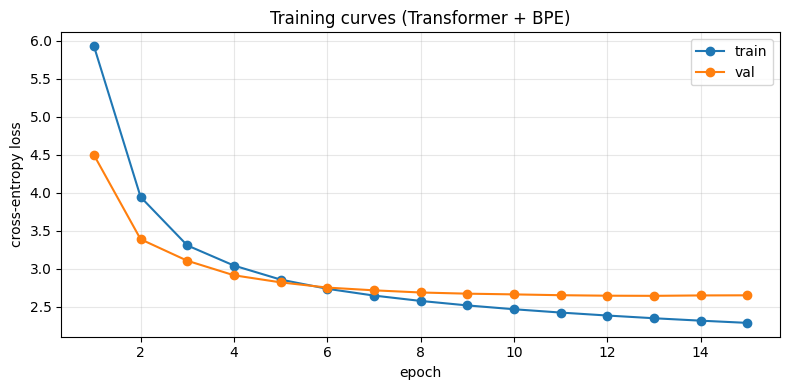

In [13]:
plt.figure(figsize=(8, 4))
xs = list(range(1, len(train_curve) + 1))
plt.plot(xs, train_curve, marker='o', label='train')
plt.plot(xs, val_curve,   marker='o', label='val')
plt.xlabel('epoch'); plt.ylabel('cross-entropy loss')
plt.title('Training curves (Transformer + BPE)')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig('curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [16]:
ckpt = torch.load('best.pt', map_location=device)
model.load_state_dict(ckpt['Model'])
model.eval()
print(f"Loaded best.pt (epoch {ckpt['epoch']}, val loss {ckpt['val_loss']:.4f})")

@torch.no_grad()
def greedy_decode_batch(src, max_len=80):
    memory, src_pad = model.encode(src)
    B = src.size(0)
    ys = torch.full((B, 1), BOS_ID, dtype=torch.long, device=device)
    finished = torch.zeros(B, dtype=torch.bool, device=device)
    for _ in range(max_len - 1):
        logits = model.decode_step(ys, memory, src_pad)
        nxt = logits[:, -1].argmax(-1)
        nxt = torch.where(finished, torch.full_like(nxt, PAD_ID), nxt)
        ys = torch.cat([ys, nxt.unsqueeze(1)], dim=1)
        finished = finished | (nxt == EOS_ID)
        if finished.all():
            break
    return ys

def ids_to_text(ids):
    out = []
    for i in ids:
        i = int(i)
        if i in (BOS_ID, PAD_ID):
            continue
        if i == EOS_ID:
            break
        out.append(i)
    return sp.decode(out)

@torch.no_grad()
def corpus_bleu(loader, name):
    refs, hyps = [], []
    for src, tgt in loader:
        src = src.to(device)
        out = greedy_decode_batch(src, max_len=80)
        for i in range(src.size(0)):
            refs.append(ids_to_text(tgt[i].tolist()))
            hyps.append(ids_to_text(out[i].tolist()))
    bleu = sacrebleu.corpus_bleu(hyps, [refs])
    print(f"[{name}] BLEU = {bleu.score:.2f}  (n={len(hyps)})")
    return bleu.score, hyps, refs

val_bleu,  val_hyps,  val_refs  = corpus_bleu(val_loader,  'val')
test_bleu, test_hyps, test_refs = corpus_bleu(test_loader, 'test')


Loaded best.pt (epoch 13, val loss 2.6410)
[val] BLEU = 30.20  (n=3000)
[test] BLEU = 29.93  (n=3000)


In [17]:
@torch.no_grad()
def beam_search(text, beam=5, max_len=80, len_penalty=0.6):
    model.eval()
    ids = [BOS_ID] + sp.encode(text.lower(), out_type=int)[:MAX_LEN - 2] + [EOS_ID]
    src = torch.tensor(ids, device=device).unsqueeze(0)
    memory, src_pad = model.encode(src)
    memory_b  = memory.expand(beam, -1, -1).contiguous()
    src_pad_b = src_pad.expand(beam, -1).contiguous()

    seqs = torch.full((beam, 1), BOS_ID, dtype=torch.long, device=device)
    scores = torch.full((beam,), -1e9, device=device); scores[0] = 0.0
    finished = []  # (normalized_score, token_list)

    for _ in range(max_len - 1):
        logits = model.decode_step(seqs, memory_b, src_pad_b)
        logp = F.log_softmax(logits[:, -1], dim=-1)
        cand = scores.unsqueeze(1) + logp                  # (beam, V)
        topk = cand.view(-1).topk(beam)
        beam_idx = topk.indices // vocab_size
        tok_idx  = topk.indices %  vocab_size
        seqs = torch.cat([seqs[beam_idx], tok_idx.unsqueeze(1)], dim=1)
        scores = topk.values

        is_eos = (tok_idx == EOS_ID)
        for b in is_eos.nonzero(as_tuple=True)[0].tolist():
            lp = ((5 + seqs.size(1)) / 6.0) ** len_penalty
            finished.append((scores[b].item() / lp, seqs[b].tolist()))
            scores[b] = -1e9

        if len(finished) >= beam:
            break

    if not finished:
        b = int(scores.argmax())
        finished.append((scores[b].item(), seqs[b].tolist()))
    finished.sort(key=lambda x: -x[0])
    return ids_to_text(finished[0][1])

samples = [
    "resumption of the session",
    "thank you for your attention",
    "i agree with the proposal",
    "climate change is a serious problem",
    "the european parliament meets today",
    "we must protect human rights and democratic values",
    "the commission has presented a new directive on energy efficiency",
]
print("Beam search (beam=5):\n")
for s in samples:
    print(f"  EN: {s}")
    print(f"  FR: {beam_search(s, beam=5)}")
    print()


Beam search (beam=5):

  EN: resumption of the session
  FR: reprise de la session

  EN: thank you for your attention
  FR: merci pour votre attention.

  EN: i agree with the proposal
  FR: je suis d'accord avec la proposition.

  EN: climate change is a serious problem
  FR: le changement climatique est un problème sérieux.

  EN: the european parliament meets today
  FR: le parlement européen se réunit aujourd'hui

  EN: we must protect human rights and democratic values
  FR: nous devons protéger les droits de l'homme et les valeurs démocratiques.

  EN: the commission has presented a new directive on energy efficiency
  FR: la commission a présenté une nouvelle directive sur l'efficacité énergétique



In [19]:
print(f"Final BLEU — val: {val_bleu:.2f}, test: {test_bleu:.2f}\n")
for i in range(8):
    print(f"Example {i}")
    print(f"REF: {test_refs[i]}")
    print(f"HYP: {test_hyps[i]}")
    print()


Final BLEU — val: 30.20, test: 29.93

Example 0
REF: mes collègues ont exprimé leur crainte à propos de certains points importants.
HYP: mes collègues ont exprimé un écho à certains points cruciaux.

Example 1
REF: les arrêts rendus montrent que l'indépendance des fédérations et que la dimension sociale du sport est prise en considération par la cour de luxembourg.
HYP: les décisions qui ont été publiées montrent que la cour de luxembourg tient compte de l'indépendance des fédérations ainsi que de la dimension sociale du sport.

Example 2
REF: en revanche, la commission ne peut pas accepter l'amendement 3, car il contredirait le principe en vigueur jusqu'ici, selon lequel les protocoles de pêche constituent des annexes des accords-cadres et donc qu'aucun mandat de négociation particulier de la part du conseil n'est nécessaire pour
HYP: toutefois, la commission ne peut accepter l'amendement 3 car elle va à l'encontre du principe appliqué jusqu'à présent, selon lequel les protocoles de l